# Correction de biais multivariée pour les modèles climatiques

In [2]:
import importlib
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import functions


In [3]:
importlib.reload(functions)

<module 'functions' from 'c:\\Users\\gmass\\Desktop\\COURS_ENSAE\\2A\\statapp\\statapp_edf_25\\functions.py'>

## Introduction
Présentation du sujet, enjeux et problématique


## Présentation des données

### 1. Données de simulation CMIP6

Le projet CMIP6 (Coupled Model Intercomparison Project Phase 6) représente la dernière génération de modèles climatiques. On utilisera donc les bases de données associées à ce modèle plutôt que CMIP5 ou eurocordex. Les données sont divisées en deux périodes

- **CMIP6_historical** : simulations historiques de 1950 à 2015
- **CMIP6_ssp585** : projections futures de 2015 à 2100 selon le scénario SSP5-8.5 (scénario d'émissions élevées)

#### Variables CMIP6
- `date` : horodatage
- `tas` : température de l'air en surface (°C ou K)
- `sfcWind` : vitesse du vent en surface (m/s)
- `rlds` : rayonnement infrarouge descendant (longwave downward, W/m²)
- `rsds` : rayonnement solaire descendant (shortwave downward, W/m²)
- `huss` : humidité en surface (kg/kg)
- `uas` : composante horizontale du vent - direction est-ouest (m/s)
- `vas` : composante verticale du vent - direction nord-sud (m/s)

### 2. Données d'observation (obs)

Les observations réelles couvrent la période de **1982 à 2022** et constituent notre référence pour la correction des modèles.

#### Variables observées
- `date` : horodatage
- `tas` : température de l'air en surface (°C ou K)
- `uas` : composante zonale du vent - direction est-ouest (m/s)
- `vas` : composante méridionale du vent - direction nord-sud (m/s)
- `rsds` : rayonnement solaire descendant (W/m²)
- `rlds` : rayonnement infrarouge descendant (W/m²)
- `hurs` : humidité relative en surface (%)

### Différences entre CMIP6 et obs

- **CMIP6** inclut `sfcWind` (vitesse totale du vent) et `huss` (humidité spécifique)
- **obs** inclut `hurs` (humidité relative au lieu de spécifique)
- Les deux datasets partagent les composantes directionnelles du vent (`uas`, `vas`) et les rayonnements (`rsds`, `rlds`)

### Note sur l'humidité

L'humidité spécifique (`huss`) et l'humidité relative (`hurs`) sont deux mesures différentes :
- **huss** : masse de vapeur d'eau par unité de masse d'air (kg/kg)
- **hurs** : rapport entre la pression de vapeur actuelle et la pression de vapeur saturante (%)

Une conversion entre ces deux variables est possible si on connaît la température et la pression.


In [4]:
modele_hist = functions.csv_to_pd(r"data\CMIP6_historical.csv")
modele_futur = functions.csv_to_pd(r"data\CMIP6_ssp585.csv")

modele = pd.concat([modele_hist, modele_futur])
obs = functions.csv_to_pd(r"data\obs.csv")

modele_hist.head()


,date,tas,sfcWind,rlds,rsds,huss,uas,vas
0,1950-01-01,-1.686420,3.114002,303.704753,22.718583,3.576517,2.596141,0.765282
1,1950-01-02,-0.590311,4.385591,309.932332,7.131182,4.024346,3.865216,1.291576
2,1950-01-03,-0.063002,4.716338,314.250186,8.028077,4.192423,4.116754,1.296945
3,1950-01-04,-3.083886,3.500701,280.008345,30.872787,3.232979,2.438605,-1.731674
4,1950-01-05,-5.368538,2.403433,260.420616,50.302147,2.641278,-0.763190,-0.472883


In [5]:
modele.head()

,date,tas,sfcWind,rlds,rsds,huss,uas,vas
0,1950-01-01,-1.686420,3.114002,303.704753,22.718583,3.576517,2.596141,0.765282
1,1950-01-02,-0.590311,4.385591,309.932332,7.131182,4.024346,3.865216,1.291576
2,1950-01-03,-0.063002,4.716338,314.250186,8.028077,4.192423,4.116754,1.296945
3,1950-01-04,-3.083886,3.500701,280.008345,30.872787,3.232979,2.438605,-1.731674
4,1950-01-05,-5.368538,2.403433,260.420616,50.302147,2.641278,-0.763190,-0.472883


In [6]:
obs['year'] = obs['date'].dt.year
obs['month'] = obs['date'].dt.month

modele['year'] = modele['date'].dt.year
modele['month'] = modele['date'].dt.month   

## Existence de biais

En se focalisant sur la variable `tas`, on prend conscience du biais du modèle CMIP6

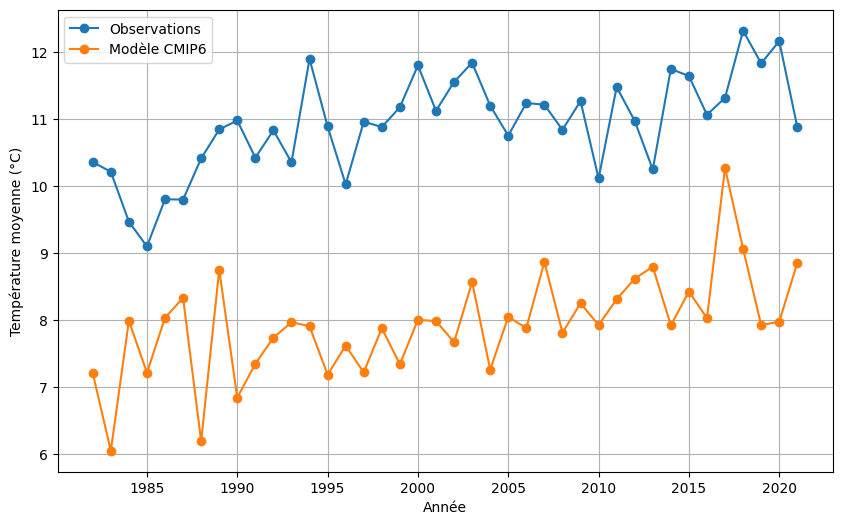

In [7]:
yobs = [obs[obs['year'] == m]['tas'].mean() for m in range(1982, 2022)]
ymodel = [modele[modele['year'] == m]['tas'].mean() for m in range(1982, 2022)]

plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('Année')
plt.ylabel('Température moyenne (°C)')
plt.plot(range(1982, 2022), yobs, 'o-', label='Observations')
plt.plot(range(1982, 2022), ymodel, 'o-', label='Modèle CMIP6')
plt.legend()
plt.show()

On observe une augmentation globale dans le modèle comme dans les observations, avec une sous-évaluation de la variable `tas` par le modèle CMIP6

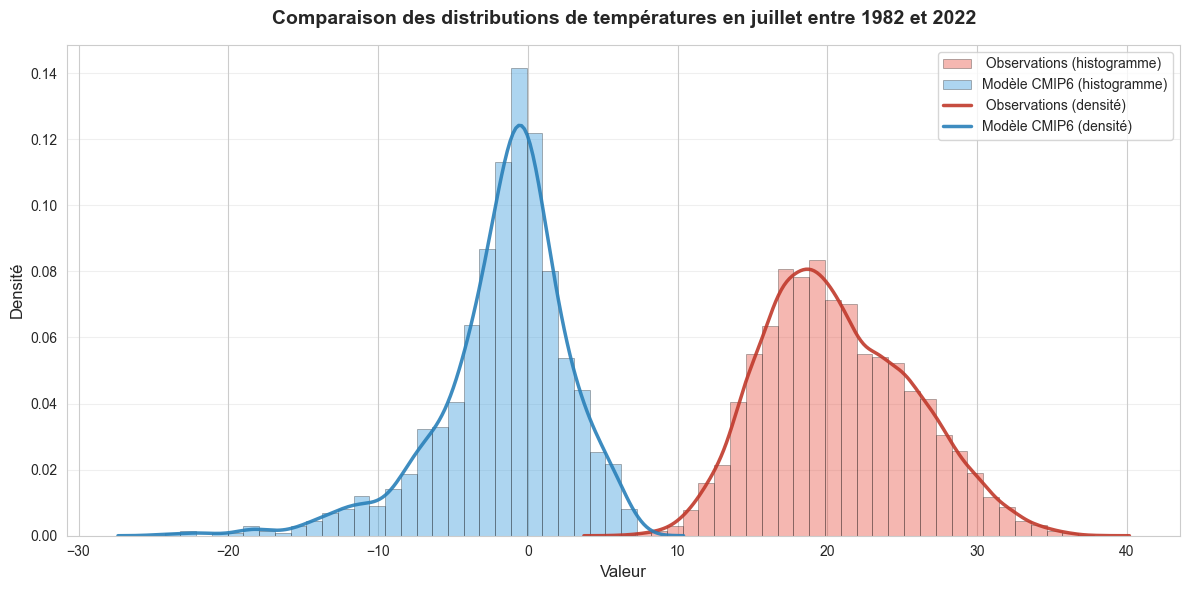

In [8]:
data1 = obs[obs['month'] == 7]['tas'] 
data2 = modele[modele['month'] == 7 & (modele['year'] >= 1982) & (modele['year'] <= 2022)]['tas']

functions.plot_distributions((data1, data2),
                             'Comparaison des distributions de températures en juillet entre 1982 et 2022',
                                ('Observations', 'Modèle CMIP6'))

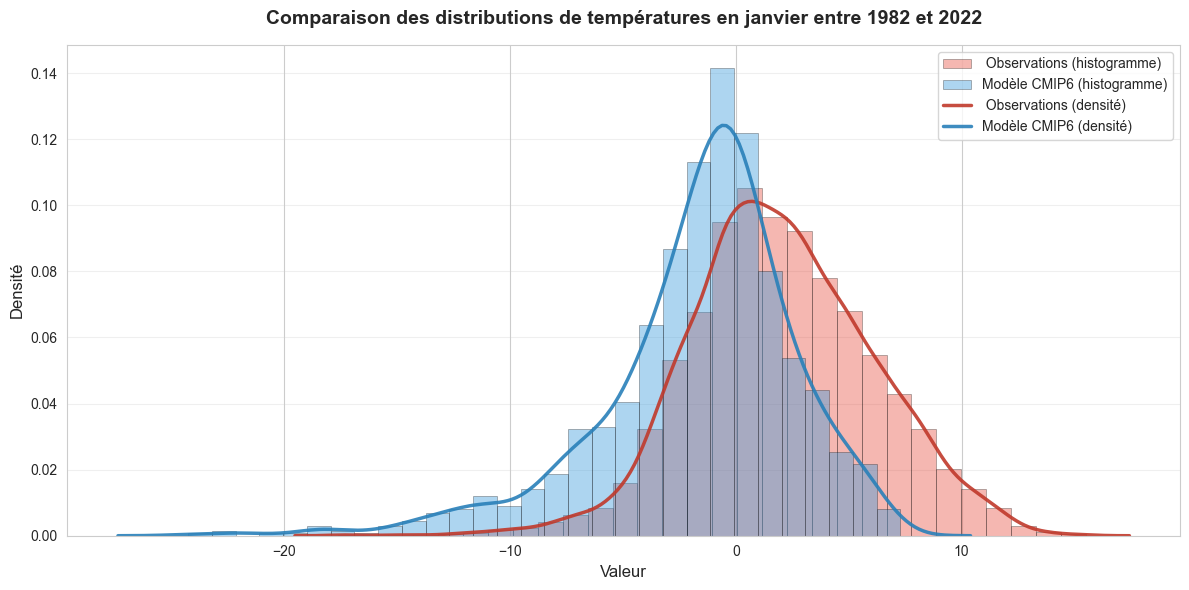

In [9]:
data1 = obs[obs['month'] == 1]['tas']
data2 = modele[modele['month'] == 1 & (modele['year'] >= 1982) & (modele['year'] <= 2022)]['tas']

functions.plot_distributions((data1, data2),
                             'Comparaison des distributions de températures en janvier entre 1982 et 2022',
                                ('Observations', 'Modèle CMIP6'))

Encore une fois, le modèle sous-évalue `tas` par rapport aux observations disponible. 

## Correction univariée du biais par quantile mapping

Le modèle CMIP6 a tendance a sous-évaluer `tas`, et il peut exister d'autres biais pour d'autres variables. Dans cette partie, nous allons tenter de corriger ces biais de façon univariée (variable par variable).

### Notations

On pose : 
- **$X_0$** : distribution du modèle dans le passé (période historique)
- **$X_1$** : distribution du modèle dans le futur (projections biaisées)
- **$Y_0$** : distribution des observations dans le passé
- **$Y_1$** : variable dont on cherche la distribution (projections non biaisées)


### Hypothèse de stationarité

Supposons que le biais entre le modèle et les observations passées est donnée par une transformation $T$ telle que 

$$F_{Y_0} = T \circ F_{X_0}$$

et que ce biais est stationnaire dans le temps, c'est à dire que l'on aura aussi dans le futur


$$F_{Y_1} = T \circ F_{X_1}$$

ce qui implique 

$$F_{Y_1} = F_{Y_0} \circ F_{X_0}^{-1} \circ F_{X_1}$$

Une fois que l'on a obtenu la fonction de répartition de $Y_1$, pour obtenir des réalisations $Y_1^i$ (observations futures corrigées), on utilise le **quantile mapping** :

$$Y_1^i = F_{Y_1}^{-1} \circ F_{X_1}(X_1^i)$$

où $X_1^i$ sont les valeurs du modèle futur.
<br><br>
En développant, on obtient :

$$Y_1^i = F_{X_1}^{-1} \circ F_{X_0} \circ F_{Y_0}^{-1} \circ F_{X_1}(X_1^i)$$


Les $Y_1^i$ sont donc sous l'hypothèse de stationnarité de meilleures projections que les $X_1^i$ issues du modèle **CMIP6**

## Tests de validité utilisant la variable `tas`
Dans un premier temps, on utilise comme données de correction les données du modèle et les observations entre 1982 et 2000 afin de comparer le modèle corrigé avec les observations de 2001 à 2022. 

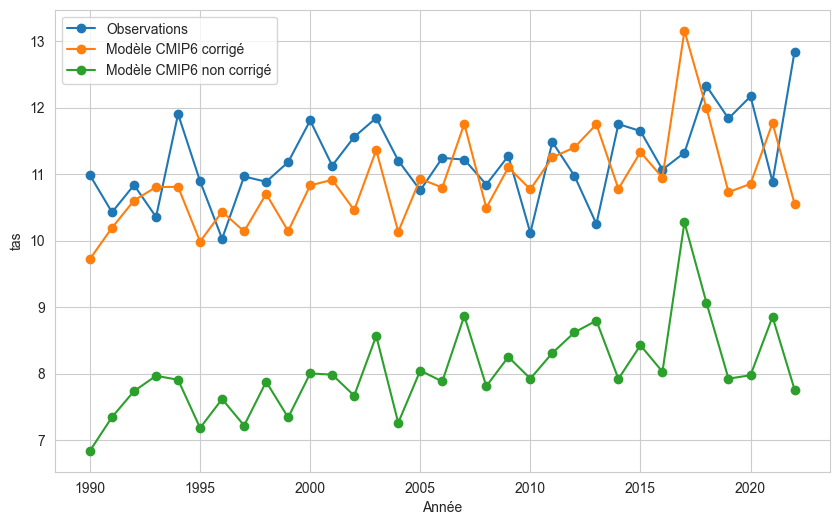

In [10]:
#correction pour tous les mois de l'année, entrainement sur les données avant 2001, test sur les données de 2001 à 2022
all_months_crossed = functions.plot_year_per_year_crossed(obs, modele, month = list(range(1, 13)), var = 'tas', first_year = 1990, last_year = 2022)

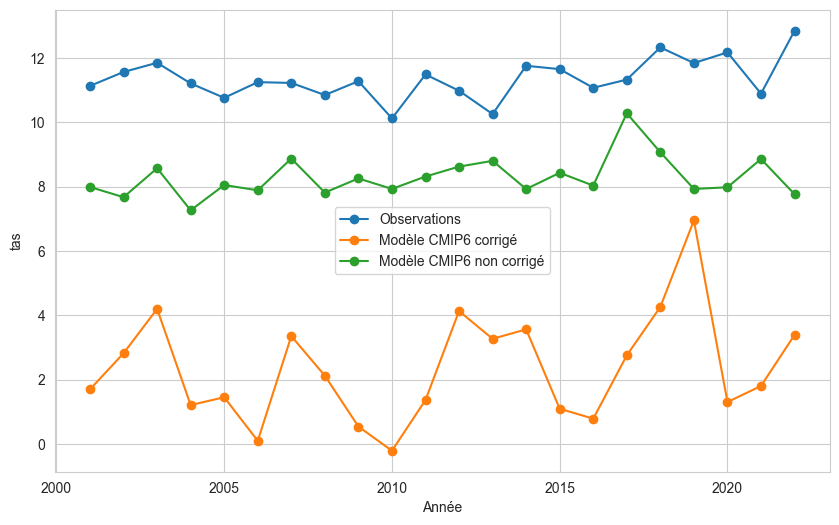

In [11]:
#correction pour le mois de janvier à mars, entrainement sur les données avant 1990, variable rsds
october_crossed = functions.plot_year_per_year_crossed(obs, modele, month=[1], var='tas', first_year=2001, last_year=2022)

Le modèle corrigé correspond mieux aux observations. A une translation près, les courbes des modèles corrigé et non corrigé sont presque identiques (mais pas exactement). 

### Comparaison entre les deux modèles

On corrige maintenant le modèle sur toutes les observations disponibles

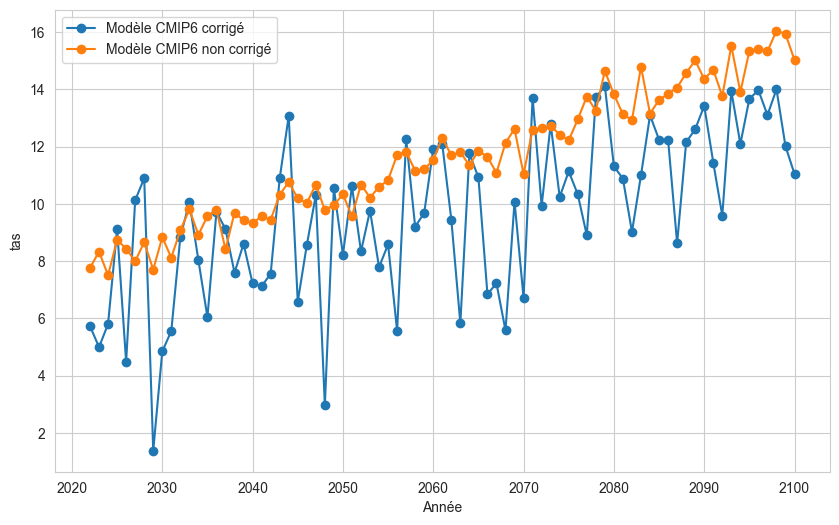

In [12]:
all_months_crossed_fut = functions.plot_year_per_year_fut(obs, modele, [3], var='tas')

Pour mesurer à quel point la correction est une translation, on peut calculer l'écart-type du delta : 

In [13]:
delta = all_months_crossed_fut['valeurs_corrigees'].values - all_months_crossed_fut['valeurs_modele'].values
std = np.std(delta)
moy = np.mean(delta)

print(f"Ecart type du delta = {std}")
print(f"Moyenne du delta = {moy}")


Ecart type du delta = 1.2286400874668861
Moyenne du delta = 4.921505760481729


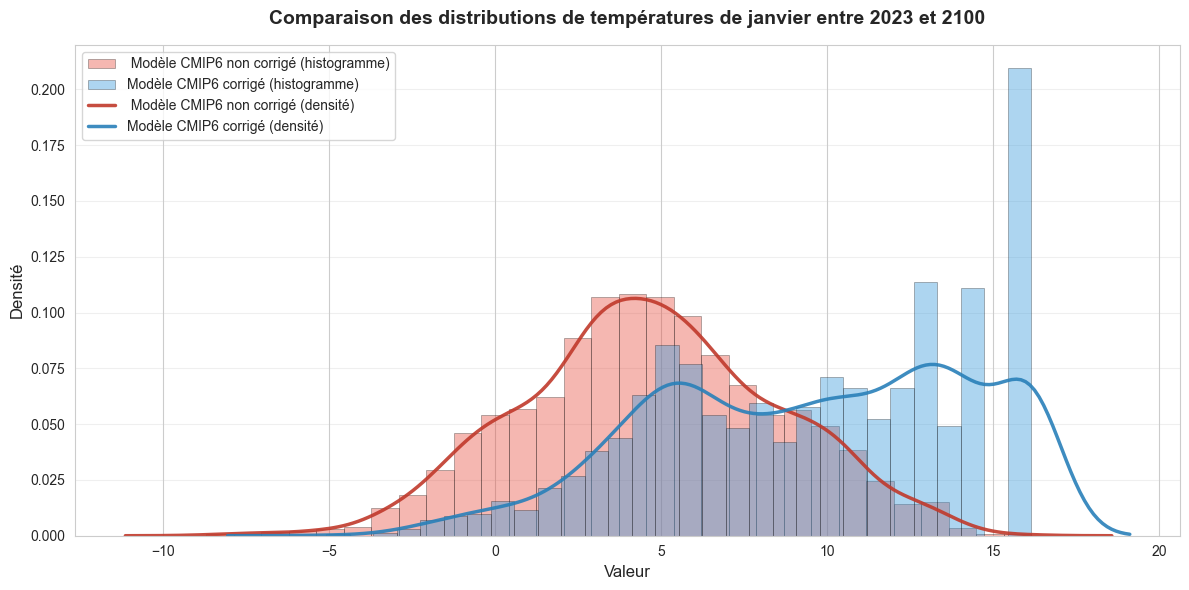

In [14]:
functions.plot_distributions((all_months_crossed_fut['valeurs_modele'].values, all_months_crossed_fut['valeurs_corrigees'].values),
    'Comparaison des distributions de températures de janvier entre 2023 et 2100',
    ('Modèle CMIP6 non corrigé', 'Modèle CMIP6 corrigé'))



## Validation théorique

On applique le quantile mapping a des variables de lois connues en générant $X_0$, $X_1$ et $Y_0$.

In [15]:
N = 10000

sigma_y0 = np.std(obs['tas'].values)
sigma_x0 = np.std(modele[modele['year'] <= 2022]['tas'].values)
sigma_x1 = np.std(modele[modele['year'] >= 2023]['tas'].values)

mu_y0 = np.mean(obs['tas'].values)
mu_x0 = np.mean(modele[modele['year'] <= 2022]['tas'].values)
mu_x1 = np.mean(modele[modele['year'] >= 2023]['tas'].values)


## on génère des lois normales

y0 = np.random.normal(mu_y0, sigma_y0, N)
x0 = np.random.normal(mu_x0, sigma_x0, N)
x1 = np.random.normal(mu_x1, sigma_x1, N)

## on applique la correction CDF-t

y1, _ = functions.cdf_t_univ(x0, y0, x1)

mu_Y1, sigma_y1, mu_th, sigma_th = np.mean(y1), np.std(y1), mu_x1 + (mu_y0 - mu_x0) * (sigma_x1 / sigma_x0), sigma_y0 * (sigma_x1 / sigma_x0)

print(f"Moyenne de la correction = {mu_Y1} ; Moyenne théorique = {mu_th}")
print(f"Ecart-type de la correction = {sigma_y1} ; Ecart-type théorique = {sigma_th}")

Moyenne de la correction = 15.669678952050061 ; Moyenne théorique = 15.507783801508086
Ecart-type de la correction = 9.07813012960609 ; Ecart-type théorique = 8.97985034088346


Les valeurs sont cohérentes

# Correction de biais dans le cas multi-dimensionnel

### Pourquoi le multidimensionnel est difficile

Dans le cas unidimensionnel, la méthode du quantile mapping apporte une correction satisfaisante. Dans le cas multidimensionnel en revanche, les variables observées n'étant pas indépendantes (par exemple, l'humidité, la température et le rayonnement solaire descendant sont clairement liés) il ne suffit plus d'apporter une correction en quantile mapping variable par variable pour capturer les corrélations entre les variables dans le modèle corrigé tout en corrigeant efficacement le biais.  


## Méthode 2 : Transport Optimal multivarié (OT)

### Problème de Monge-Kantorovich

Le transport optimal cherche un **couplage** $\pi$ entre deux distributions $\mu_0$ et $\mu_1$ minimisant le coût de transport quadratique :

$$\pi^* = \underset{\pi \in \Pi(\mu_0, \mu_1)}{\arg\min} \int_{\mathbb{R}^d \times \mathbb{R}^d} \|x_0 - x_1\|^2 \, d\pi(x_0, x_1)$$

Dans le cas empirique (nuage de $n$ points), cela revient à un **programme linéaire** sur la matrice de transport $T \in \mathbb{R}^{n_0 \times n_1}_+$ :

$$\min_{T \geq 0} \; \sum_{i,j} C_{ij} T_{ij} \qquad \text{s.c.} \quad \sum_j T_{ij} = a_i, \quad \sum_i T_{ij} = b_j$$

où $C_{ij} = \|X_0^i - X_1^j\|^2$ et $a_i = 1/n_0$, $b_j = 1/n_1$ sont des poids uniformes.

### Hypothèse de stationarité multivariée

Comme pour CDF-t, on suppose que le **biais du modèle est stationnaire** : la façon dont le modèle évolue de $X_0$ vers $X_1$ est représentative de l'évolution des observations de $Y_0$ vers $Y_1$. On calcule le plan de transport $T^*$ entre $X_0$ et $X_1$, puis on le transfère à $Y_0$ :

1. Résoudre le transport optimal $T^*$ entre $X_0$ (modèle passé) et $X_1$ (modèle futur)
2. Pour chaque $Y_0^k$, trouver son plus proche voisin $X_0^{i^*}$ dans l'espace historique
3. **Affectation dure** : $Y_1^k = X_1^{j^*}$ où $j^* = \arg\max_j T^*_{i^* j}$

### Normalisation préalable

Avant de calculer les distances, chaque variable est standardisée ($z$-score), pour que des variables d'échelles très différentes (tas en °C, rsds en W/m²) contribuent de manière équitable au coût de transport.

### Avantage multivarié

Contrairement au CDF-t variable par variable, le transport optimal déplace **conjointement** les vecteurs $(x^{(1)}_0, \ldots, x^{(d)}_0)$, préservant les **corrélations inter-variables** de la correction.

## Méthode 3 : Pont de Schrödinger (SB)

### Limites du transport optimal classique

La solution EMD est **sparse** : chaque $X_0^i$ est affecté à exactement un $X_1^j$. Cela produit des corrections discontinues, potentiellement instables avec peu de données ou en grande dimension.

### Problème de Schrödinger (1931–1932)

Erwin Schrödinger posa en 1931 la question suivante : étant donné la distribution initiale $\mu_0$ et finale $\mu_1$ d'un nuage de particules browniennes, quel est le **processus stochastique le plus probable** qui les relie ?

En termes modernes, il s'agit d'un transport optimal **régularisé par entropie** :

$$\pi^\varepsilon = \underset{\pi \in \Pi(\mu_0, \mu_1)}{\arg\min} \underbrace{\int c \, d\pi}_{\text{coût OT}} + \; \varepsilon \; \underbrace{\mathrm{KL}\!\left(\pi \,\big\|\, R^\varepsilon\right)}_{\text{prior de diffusion}}$$

où le **prior de diffusion** est le noyau brownien :

$$R^\varepsilon(x_0, x_1) \propto \exp\!\left(-\frac{\|x_0 - x_1\|^2}{2\varepsilon}\right)$$

La divergence $\mathrm{KL}(\pi \| R^\varepsilon)$ pénalise les couplages qui s'éloignent trop du mouvement brownien. Le paramètre $\varepsilon > 0$ contrôle l'intensité de la régularisation.

### Algorithme de Sinkhorn

La solution s'écrit sous la forme tensorisée :

$$T^\varepsilon_{ij} = u_i \cdot \underbrace{\exp\!\left(-\frac{C_{ij}}{\varepsilon}\right)}_{K_{ij}} \cdot v_j$$

où $u \in \mathbb{R}^{n_0}$ et $v \in \mathbb{R}^{n_1}$ sont les **potentiels duaux** calculés par l'algorithme de Sinkhorn :

$$u^{(t+1)} = \frac{a}{K v^{(t)}}, \qquad v^{(t+1)} = \frac{b}{K^\top u^{(t+1)}}$$

jusqu'à convergence. La complexité est **$O(n^2)$ par itération** — bien plus rapide que l'EMD en $O(n^3)$.

### Projection barycentrique douce

La matrice $T^\varepsilon$ est **dense** (toutes les entrées sont strictement positives). Pour chaque observation corrigée, on calcule une **moyenne pondérée** de tous les points futurs :

$$Y_1^k = \frac{\displaystyle\sum_{j} T^\varepsilon_{i^*(k),\, j} \cdot X_1^j}{\displaystyle\sum_{j} T^\varepsilon_{i^*(k),\, j}}, \qquad i^*(k) = \arg\min_i \|Y_0^k - X_0^i\|$$

Cette moyenne lisse remplace l'affectation dure du transport classique, produisant des corrections **plus régulières**.

### Rôle du paramètre $\varepsilon$

| $\varepsilon$ | Comportement |
|:---:|:---|
| $\varepsilon \to 0$ | $\pi^\varepsilon \to \pi^*_{\text{OT}}$ : transport classique (affectation dure) |
| $\varepsilon$ modéré | Corrections lisses, préservation des corrélations |
| $\varepsilon \to \infty$ | $\pi^\varepsilon \to \mu_0 \otimes \mu_1$ : couplage indépendant (aucune correction) |

### Synthèse des trois méthodes

|  | CDF-t | OT | Pont de Schrödinger |
|---|:---:|:---:|:---:|
| Traitement des variables | Marginales indépendantes | Joint $\mathbb{R}^d$ | Joint $\mathbb{R}^d$ |
| Corrélations préservées | ✗ | ✓ | ✓ |
| Affectation | Quantile (continue) | Dure (argmax de $T$) | Douce (barycentre de $T^\varepsilon$) |
| Régularisation | — | $\varepsilon = 0$ | $\varepsilon > 0$ |
| Complexité | $O(n \log n)$ / var. | $O(n^3)$ | $O(n^2)$ / itération |

In [16]:
np.random.seed(42)
N_ex = 500

# Observations passées : corrélation cible ρ ≈ 0.5
mean_obs  = [18, 200]
cov_obs   = [[16, 28.0], [28.0, 3600]]    # ρ = 28 / (4 * 60) ≈ 0.117 → cible

# Modèle (biais en moyenne ET en covariance)
mean_model = [14, 220]
cov_model  = [[25, 10.0], [10.0, 4900]]

Y0 = np.random.multivariate_normal(mean_obs,  cov_obs,   N_ex)
X0 = np.random.multivariate_normal(mean_model, cov_model, N_ex)
X1 = np.random.multivariate_normal([m + 2 for m in mean_model], cov_model, N_ex)

rho_target = np.corrcoef(Y0.T)[0, 1]
print(f"Corrélation cible  (obs Y0) : {rho_target:.3f}")
print(f"Corrélation modèle futur X1 : {np.corrcoef(X1.T)[0, 1]:.3f}")
print()

Y1_cdf         = functions.cdf_t_multivar(X0, Y0, X1)
Y1_ot,  _      = functions.transport_optimal(X0, Y0, X1, method='emd',      normalize=True)
Y1_sb,  _      = functions.schrodinger_bridge(X0, Y0, X1, reg=0.3,          normalize=True)

print(f"{'Méthode':<20} {'ρ estimé':>10}  {'|erreur|':>10}")
print("-" * 44)
for name, Y1 in [("CDF-t",       Y1_cdf),
                 ("OT (EMD)",     Y1_ot),
                 ("SB (ε=0.3)",   Y1_sb)]:
    rho = np.corrcoef(Y1.T)[0, 1]
    err = abs(rho - rho_target)
    print(f"{name:<20} {rho:>10.3f}  {err:>10.3f}")

Corrélation cible  (obs Y0) : 0.088
Corrélation modèle futur X1 : 0.073

Méthode                ρ estimé    |erreur|
--------------------------------------------
CDF-t                     0.071       0.017
OT (EMD)                  0.121       0.033
SB (ε=0.3)                0.169       0.082


Sur cet exemple 2D, OT et SB récupèrent mieux la corrélation de $Y_0$ que le CDF-t naïf, qui corrige chaque variable indépendamment et ne peut donc pas restaurer la structure de dépendance jointe.

Le reste de ce notebook compare systématiquement les trois méthodes sur des données simulées gaussiennes (distribution connue, évaluation exacte possible), puis sur les données réelles CMIP6.

# Benchmark comparatif des trois méthodes

Deux métriques sont utilisées :

- **Distance de Wasserstein** (d=1) : $W_1(\hat{Y}_1, Y_0)$ — coût de transport entre la distribution corrigée et les observations. Mesure l'écart marginal.
- **Frobenius corrélation** (d≥2) : $\|R_{\hat{Y}_1} - R_{Y_0}\|_F$ — norme de Frobenius de la différence entre matrices de corrélation. **Sans dimension**, robuste aux différences d'échelle entre variables.

La seconde métrique est préférable à la Frobenius sur la covariance brute, car elle ne dépend pas des unités (°C vs W/m²).

In [17]:
variables = []

for variable in modele.columns:
    if variable in obs.columns and variable != 'date' and variable != 'year' and variable != 'month':
        print(variable)
        variables.append(variable)



tas
rlds
rsds
uas
vas


In [18]:
importlib.reload(functions)

<module 'functions' from 'c:\\Users\\gmass\\Desktop\\COURS_ENSAE\\2A\\statapp\\statapp_edf_25\\functions.py'>

## 1. Données simulées gaussiennes : récupération des corrélations en fonction de $d$

On génère des triplets $(X_0, Y_0, X_1)$ gaussiens multivariés avec des matrices de covariance aléatoires, et on mesure la capacité de chaque méthode à récupérer la structure de corrélation de $Y_0$ dans la correction $\hat{Y}_1$. L'expérience est répétée avec plusieurs graines pour lisser la variabilité d'échantillonnage.

In [19]:
importlib.reload(functions)

dims  = [1, 2, 4, 6]
seeds = range(5)

gauss_results = {d: {'cdf_t': [], 'ot': [], 'sb': []} for d in dims}

for d in dims:
    for seed in seeds:
        res, _ = functions.gaussian_multivar_test(d=d, N=400, N_fut=200, reg_sb=0.3, seed=seed)
        for method in ['cdf_t', 'ot', 'sb']:
            # d=1 : Wasserstein (pas de corrélation à comparer) ; d>1 : Frobenius corrélation
            val = res[method]['wasserstein'] if d == 1 else res[method]['frobenius_corr']
            gauss_results[d][method].append(val)

metric_label = {1: 'Wasserstein', 2: 'Frobenius corr', 4: 'Frobenius corr', 6: 'Frobenius corr'}

print(f"{'d':>3}  {'Métrique':<18}  {'CDF-t':>8}  {'OT (EMD)':>10}  {'SB (ε=0.3)':>12}")
print("-" * 60)
for d in dims:
    means = {m: np.mean(gauss_results[d][m]) for m in ['cdf_t', 'ot', 'sb']}
    best  = min(means.values())
    mark  = lambda v: ' ←' if abs(v - best) < 1e-9 else ''
    print(f"{d:>3}  {metric_label[d]:<18}  "
          f"{means['cdf_t']:>8.4f}  "
          f"{means['ot']:>10.4f}{mark(means['ot']):<2}  "
          f"{means['sb']:>12.4f}{mark(means['sb']):<2}")

c:\Users\gmass\AppData\Local\Programs\Python\Python311\Lib\site-packages\ot\bregman\_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


  d  Métrique               CDF-t    OT (EMD)    SB (ε=0.3)
------------------------------------------------------------
  1  Wasserstein           1.2775      1.6316          1.3139  
  2  Frobenius corr        0.3633      0.3045 ←        0.3240  
  4  Frobenius corr        0.7888      1.2109          1.0399  
  6  Frobenius corr        1.2282      2.3759          2.1025  


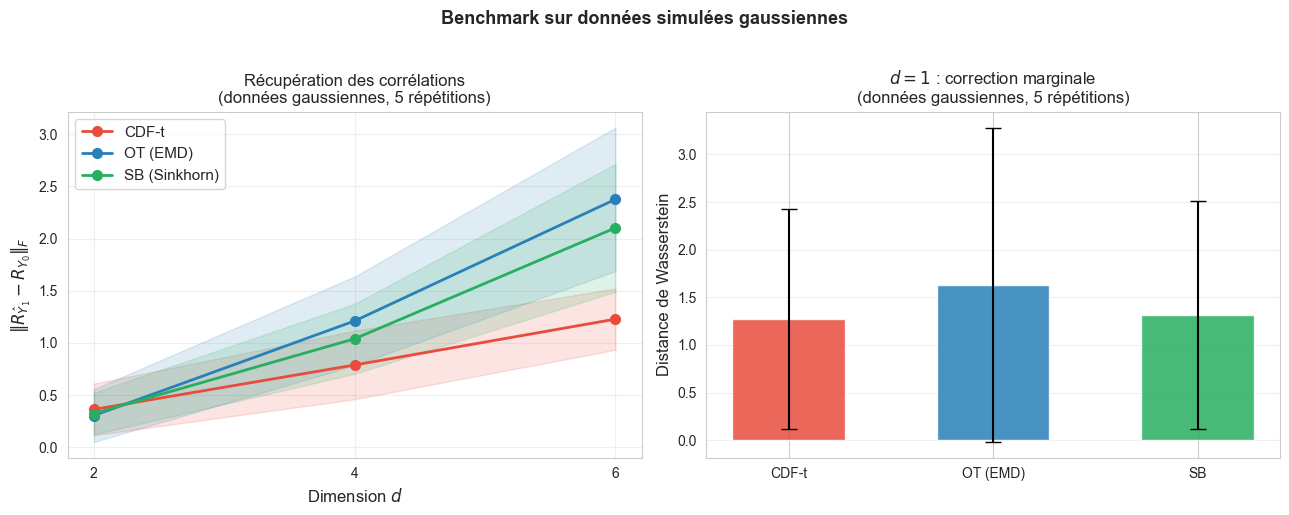

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'cdf_t': '#e74c3c', 'ot': '#2980b9', 'sb': '#27ae60'}
labels = {'cdf_t': 'CDF-t', 'ot': 'OT (EMD)', 'sb': 'SB (Sinkhorn)'}

# Panneau gauche : Frobenius corrélation vs dimension (d ≥ 2)
dims_plot = [d for d in dims if d > 1]
for method in ['cdf_t', 'ot', 'sb']:
    means = [np.mean(gauss_results[d][method]) for d in dims_plot]
    stds  = [np.std(gauss_results[d][method])  for d in dims_plot]
    axes[0].plot(dims_plot, means, 'o-', color=colors[method], label=labels[method], linewidth=2, markersize=7)
    axes[0].fill_between(dims_plot,
                         [m - s for m, s in zip(means, stds)],
                         [m + s for m, s in zip(means, stds)],
                         alpha=0.15, color=colors[method])
axes[0].set_xlabel('Dimension $d$', fontsize=12)
axes[0].set_ylabel(r'$\|R_{\hat{Y}_1} - R_{Y_0}\|_F$', fontsize=12)
axes[0].set_title('Récupération des corrélations\n(données gaussiennes, 5 répétitions)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(dims_plot)

# Panneau droit : Wasserstein pour d=1 (correction marginale)
x_pos = np.arange(3)
for k, (method, xp) in enumerate(zip(['cdf_t', 'ot', 'sb'], x_pos)):
    vals = gauss_results[1][method]
    axes[1].bar(xp, np.mean(vals), yerr=np.std(vals),
                color=colors[method], label=labels[method], alpha=0.85, capsize=6, width=0.55)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['CDF-t', 'OT (EMD)', 'SB'])
axes[1].set_ylabel('Distance de Wasserstein', fontsize=12)
axes[1].set_title('$d = 1$ : correction marginale\n(données gaussiennes, 5 répétitions)', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Benchmark sur données simulées gaussiennes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Application sur les données réelles CMIP6

On applique les trois méthodes aux données réelles pour le mois de **janvier**, qui est le mois le plus froid et présente le biais en `tas` le plus fort.

### 2a. Comparaison multivariée : récupération des corrélations selon $d$

On évalue la capacité de chaque méthode à reproduire la structure de corrélation des observations passées dans la correction future, en ajoutant les variables une par une.

In [21]:
obs_past = obs[(obs['year'] >= 1982) & (obs['year'] <= 2022) & (obs['month'] == 1)]
mod_past  = modele[(modele['year'] >= 1982) & (modele['year'] <= 2022) & (modele['month'] == 1)]
mod_fut   = modele[(modele['year'] >= 2023) & (modele['month'] == 1)]

print(f"{'d':>3}  {'Variables':<42}  {'CDF-t':>8}  {'OT':>8}  {'SB':>8}  ← Frobenius corrélation")
print("-" * 85)

real_frob = {'cdf_t': [], 'ot': [], 'sb': []}

for i in range(len(variables)):
    liste = variables[:i + 1]
    Y0 = obs_past[liste].values
    X0 = mod_past[liste].values
    X1 = mod_fut[liste].values

    Y1_q        = functions.cdf_t_multivar(X0, Y0, X1)
    Y1_ot, _    = functions.transport_optimal(X0, Y0, X1, method='emd', normalize=True)
    Y1_sb, _    = functions.schrodinger_bridge(X0, Y0, X1, reg=0.3, normalize=True)

    e_q  = functions.correlation_frobenius(Y0, Y1_q)
    e_ot = functions.correlation_frobenius(Y0, Y1_ot)
    e_sb = functions.correlation_frobenius(Y0, Y1_sb)

    real_frob['cdf_t'].append(e_q)
    real_frob['ot'].append(e_ot)
    real_frob['sb'].append(e_sb)

    best = min(e_q, e_ot, e_sb)
    mark = lambda e: ' ←' if abs(e - best) < 1e-9 else '   '
    print(f"{i+1:>3}  {str(liste):<42}  {e_q:>8.4f}  {e_ot:>8.4f}{mark(e_ot)}  {e_sb:>8.4f}{mark(e_sb)}")

  d  Variables                                      CDF-t        OT        SB  ← Frobenius corrélation
-------------------------------------------------------------------------------------
  1  ['tas']                                       0.0000    0.0000 ←    0.0000 ←
  2  ['tas', 'rlds']                               0.0610    0.1604       0.0248 ←
  3  ['tas', 'rlds', 'rsds']                       1.2810    0.9422 ←    1.1105   
  4  ['tas', 'rlds', 'rsds', 'uas']                1.4100    0.9007 ←    1.1091   
  5  ['tas', 'rlds', 'rsds', 'uas', 'vas']         1.8957    1.3087 ←    1.3569   


### 2b. Validation croisée univariée sur `tas` (toutes les saisons)

Pour évaluer honnêtement la qualité de correction **sur les données que l'on possède**, on effectue une validation croisée :
- **Entraînement** : 1982–2005
- **Test** : application à `modele(2006–2022)` et comparaison avec `obs(2006–2022)` via la distance de Wasserstein 1D

Cela permet de mesurer si la correction extrapolée sur la période de test est réellement plus proche des observations que le modèle brut.

In [22]:
from scipy.stats import wasserstein_distance

train_end   = 2005
test_start  = 2006
test_end    = 2022
var_xval    = 'tas'

month_names = {1:'Jan', 2:'Fév', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Jun',
               7:'Jul', 8:'Aoû', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Déc'}

wass_xval = {m: {} for m in range(1, 13)}

for m in range(1, 13):
    Y0_tr = obs[(obs['year'] <= train_end)  & (obs['month'] == m)][[var_xval]].values
    X0_tr = modele[(modele['year'] <= train_end)  & (modele['month'] == m)][[var_xval]].values
    X1_te = modele[(modele['year'] >= test_start) & (modele['year'] <= test_end) & (modele['month'] == m)][[var_xval]].values
    Y0_te = obs[(obs['year'] >= test_start) & (obs['year'] <= test_end)  & (obs['month'] == m)][[var_xval]].values

    Y1_q        = functions.cdf_t_multivar(X0_tr, Y0_tr, X1_te)
    Y1_ot, _    = functions.transport_optimal(X0_tr, Y0_tr, X1_te, method='emd', normalize=True)
    Y1_sb, _    = functions.schrodinger_bridge(X0_tr, Y0_tr, X1_te, reg=0.3, normalize=True)

    ref = Y0_te.flatten()
    wass_xval[m]['raw']   = wasserstein_distance(X1_te.flatten(), ref)
    wass_xval[m]['cdf_t'] = wasserstein_distance(Y1_q.flatten(),  ref)
    wass_xval[m]['ot']    = wasserstein_distance(Y1_ot.flatten(), ref)
    wass_xval[m]['sb']    = wasserstein_distance(Y1_sb.flatten(), ref)

print(f"{'Mois':<6}  {'Brut':>8}  {'CDF-t':>8}  {'OT':>8}  {'SB':>8}  (Wasserstein vs obs 2006-2022)")
print("-" * 60)
for m in range(1, 13):
    v = wass_xval[m]
    best = min(v['cdf_t'], v['ot'], v['sb'])
    mk = lambda x: '*' if abs(x - best) < 1e-9 else ' '
    print(f"{month_names[m]:<6}  {v['raw']:>8.4f}  {v['cdf_t']:>7.4f}{mk(v['cdf_t'])}  "
          f"{v['ot']:>7.4f}{mk(v['ot'])}  {v['sb']:>7.4f}{mk(v['sb'])}")

Mois        Brut     CDF-t        OT        SB  (Wasserstein vs obs 2006-2022)
------------------------------------------------------------
Jan       3.6193   0.6362*   0.6606    0.6880 
Fév       3.4063   0.8047    0.7627*   1.1145 
Mar       4.6185   0.7573*   0.8038    0.8244 
Avr       5.1521   1.2281*   1.2368    1.2858 
Mai       3.7222   1.5481    0.9777*   1.4173 
Jun       4.2163   0.8443*   0.9471    1.0395 
Jul       2.4883   1.1337*   1.2515    1.1450 
Aoû       2.0308   1.3578    1.2610*   1.3783 
Sep       1.4938   1.0708    0.9935*   1.1733 
Oct       2.1173   0.6747*   0.7271    0.9404 
Nov       1.8837   0.3149    0.2694    0.2222*
Déc       1.8623   1.2596    0.9996*   1.3562 


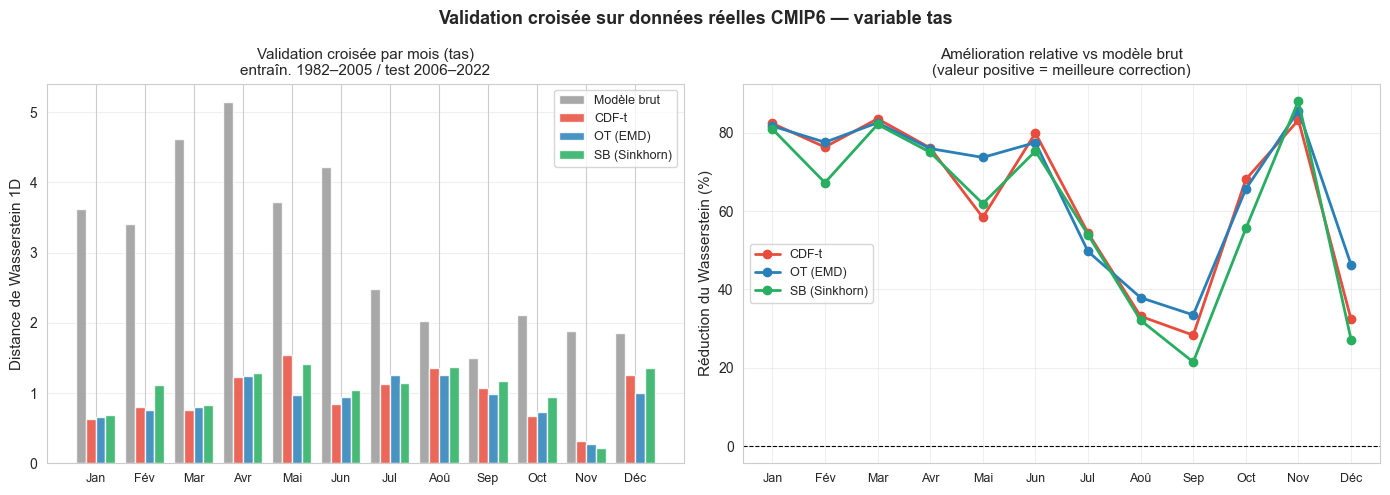

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mois_list = list(range(1, 13))
x = np.arange(12)
w = 0.2

# Panneau gauche : Wasserstein par mois (barres groupées)
for offset, key, color, label in [
        (-1.5*w, 'raw',   '#999999', 'Modèle brut'),
        (-0.5*w, 'cdf_t', '#e74c3c', 'CDF-t'),
        ( 0.5*w, 'ot',    '#2980b9', 'OT (EMD)'),
        ( 1.5*w, 'sb',    '#27ae60', 'SB (Sinkhorn)')]:
    vals = [wass_xval[m][key] for m in mois_list]
    axes[0].bar(x + offset, vals, width=w, color=color, label=label, alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels([month_names[m] for m in mois_list], fontsize=9)
axes[0].set_ylabel('Distance de Wasserstein 1D', fontsize=11)
axes[0].set_title('Validation croisée par mois (tas)\nentraîn. 1982–2005 / test 2006–2022', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis='y')

# Panneau droit : amélioration relative sur le modèle brut
for key, color, label in [('cdf_t', '#e74c3c', 'CDF-t'),
                           ('ot',    '#2980b9', 'OT (EMD)'),
                           ('sb',    '#27ae60', 'SB (Sinkhorn)')]:
    amelioration = [(wass_xval[m]['raw'] - wass_xval[m][key]) / wass_xval[m]['raw'] * 100
                    for m in mois_list]
    axes[1].plot(x, amelioration, 'o-', color=color, label=label, linewidth=2, markersize=6)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(x)
axes[1].set_xticklabels([month_names[m] for m in mois_list], fontsize=9)
axes[1].set_ylabel('Réduction du Wasserstein (%)', fontsize=11)
axes[1].set_title('Amélioration relative vs modèle brut\n(valeur positive = meilleure correction)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Validation croisée sur données réelles CMIP6 — variable tas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2c. Projections futures 2023–2100

On entraîne sur toutes les observations disponibles (1982–2022) et on projette les trois corrections jusqu'en 2100 pour le mois de janvier.

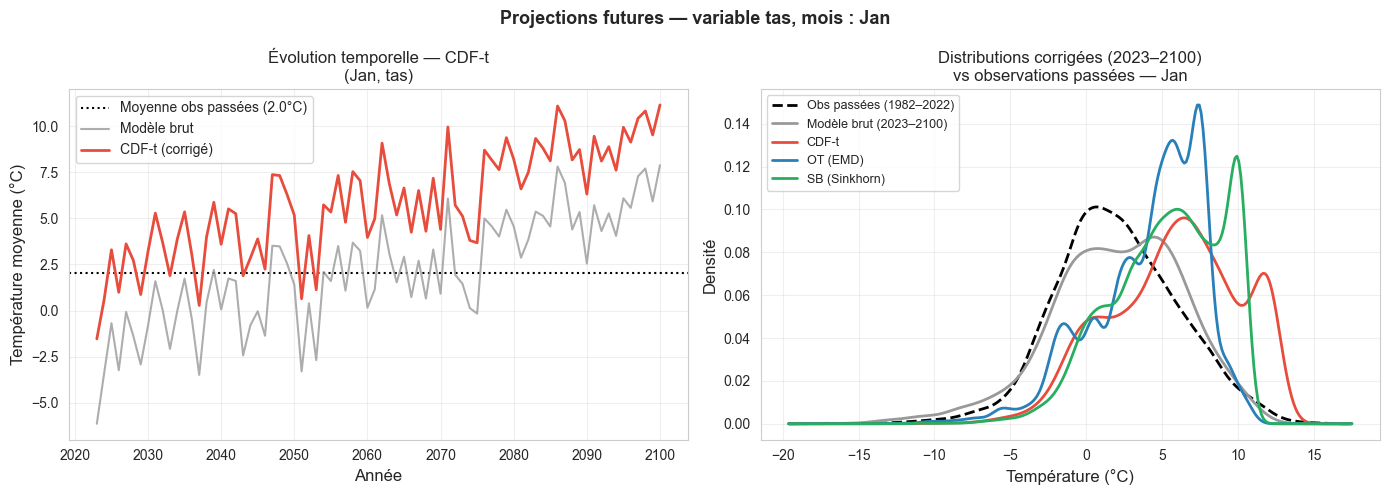

In [24]:
month_proj = 1
var_proj   = 'tas'

Y0_full = obs[(obs['year'] >= 1982) & (obs['year'] <= 2022) & (obs['month'] == month_proj)][[var_proj]].values
X0_full = modele[(modele['year'] >= 1982) & (modele['year'] <= 2022) & (modele['month'] == month_proj)][[var_proj]].values
X1_full = modele[(modele['year'] >= 2023) & (modele['month'] == month_proj)][[var_proj]].values
years_fut = modele[(modele['year'] >= 2023) & (modele['month'] == month_proj)]['year'].values

Y1_q_f      = functions.cdf_t_multivar(X0_full, Y0_full, X1_full)   # (|X1|, 1)
Y1_ot_f, _  = functions.transport_optimal(X0_full, Y0_full, X1_full, method='emd', normalize=True)  # (|Y0|, 1)
Y1_sb_f, _  = functions.schrodinger_bridge(X0_full, Y0_full, X1_full, reg=0.3, normalize=True)      # (|Y0|, 1)

# --- Panneau gauche : évolution temporelle (CDF-t seulement, taille = |X1|) ----------------
def annual_mean(values, years):
    yrs = np.unique(years)
    return yrs, np.array([values[years == y].mean() for y in yrs])

yrs, raw_annual = annual_mean(X1_full.flatten(), years_fut)
yrs, cdf_annual = annual_mean(Y1_q_f.flatten(), years_fut)
obs_mean_past   = Y0_full.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].axhline(obs_mean_past, color='black', linestyle=':', linewidth=1.5,
                label=f'Moyenne obs passées ({obs_mean_past:.1f}°C)')
axes[0].plot(yrs, raw_annual, color='#999999', linewidth=1.5, label='Modèle brut', alpha=0.8)
axes[0].plot(yrs, cdf_annual, color='#e74c3c', linewidth=2,   label='CDF-t (corrigé)')
axes[0].set_xlabel('Année', fontsize=12)
axes[0].set_ylabel('Température moyenne (°C)', fontsize=12)
axes[0].set_title(f'Évolution temporelle — CDF-t\n({month_names[month_proj]}, {var_proj})', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# --- Panneau droit : comparaison des distributions (tous les mois 2023-2100) ----------------
import scipy.stats as scipy_stats
x_grid = np.linspace(
    min(Y0_full.min(), X1_full.min(), Y1_q_f.min(), Y1_ot_f.min(), Y1_sb_f.min()) - 2,
    max(Y0_full.max(), X1_full.max(), Y1_q_f.max(), Y1_ot_f.max(), Y1_sb_f.max()) + 2,
    300
)
for vals, color, label in [
        (Y0_full.flatten(),  'black',   'Obs passées (1982–2022)'),
        (X1_full.flatten(),  '#999999', 'Modèle brut (2023–2100)'),
        (Y1_q_f.flatten(),   '#e74c3c', 'CDF-t'),
        (Y1_ot_f.flatten(),  '#2980b9', 'OT (EMD)'),
        (Y1_sb_f.flatten(),  '#27ae60', 'SB (Sinkhorn)')]:
    kde = scipy_stats.gaussian_kde(vals)
    axes[1].plot(x_grid, kde(x_grid), linewidth=2, color=color, label=label,
                 linestyle='--' if 'Obs' in label else '-')

axes[1].set_xlabel('Température (°C)', fontsize=12)
axes[1].set_ylabel('Densité', fontsize=12)
axes[1].set_title(f'Distributions corrigées (2023–2100)\nvs observations passées — {month_names[month_proj]}', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Projections futures — variable {var_proj}, mois : {month_names[month_proj]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()